# COMP9444 Group Project — Fruit and Vegetable Freshness Assessment

**Submission mode:** one self-contained, pre-executed notebook. All Person 5 integration,
evaluation, fusion, plotting, reporting, and validation-selection code is contained below. It
does not depend on project Python files, result CSV files, or PNG paths from GitHub.

**Task:** binary classification of **fresh** vs **rotten** produce.

**Pipeline:** image → ImageNet-pretrained CNN → deep feature → optional PCA → SVM/LDA/Bagging.

**Protocol:** one stratified 70/15/15 split, seed 42; RGB 224×224; ImageNet normalisation;
augmentation on training only; scaler/PCA fitted on training only; validation used for selection.
The test split is not extracted, loaded, fitted, predicted, or re-evaluated in this notebook.

The notebook has two clearly separated modes:

1. **Submission/render mode (`RUN_FULL_REPRODUCTION=False`, default):** displays the real recorded
   project outputs embedded in this notebook. This makes every output visible to a marker without
   downloading data or rerunning hours of GPU work.
2. **Full reproduction mode (`RUN_FULL_REPRODUCTION=True`):** downloads the public Kaggle dataset
   and official torchvision ImageNet weights, then reconstructs the split and reruns the complete
   train/validation pipeline from images.

Recorded values are never represented as newly computed results. Full reproduction is expensive
because it includes DenseNet-201, ResNeXt-101, frozen ResNet-18, fusion, and the classical
validation grid. Neither mode performs a new test evaluation.

## 1. Objectives and responsibilities

1. Reconstruct the agreed original split without changing its ratios, stratification or seed.
2. Extract frozen ImageNet features using DenseNet-201 and ResNeXt-101 as the main backbones.
3. Compare no augmentation and mild train-only augmentation.
4. Compare no PCA and PCA(95%) with SVM, LDA and Bagging.
5. Fuse the 1,920-dimensional DenseNet and 2,048-dimensional ResNeXt features into a 3,968-dimensional representation.
6. Evaluate frozen ResNet-18 features with no augmentation, PCA(95%), and SVM as a separate comparison baseline.
7. Report Accuracy, macro Precision, macro Recall, Macro-F1, Weighted-F1, per-class results, confusion matrices, feature dimensions, and runtime.
8. Select the final configuration using validation Macro-F1 only.

In [ ]:
import copy
import io
import json
import os
import platform
import random
import sys
import time
import warnings
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import clear_output, display
from PIL import Image, ImageOps, UnidentifiedImageError
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
IMAGE_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
CLASSES = np.asarray(["fresh", "rotten"])
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}
DATASET_HANDLE = "muhriddinmuxiddinov/fruits-and-vegetables-dataset"

# Keep False for the submitted, already-executed notebook. Set True only in a GPU runtime when a
# full from-images reproduction is intentionally required. Evaluates validation only.
RUN_FULL_REPRODUCTION = False

WORK_DIR = Path("/content/comp9444_person5") if Path("/content").is_dir() else Path.cwd() / "comp9444_person5"
FEATURE_DIR = WORK_DIR / "features"
MODEL_DIR = WORK_DIR / "models"
RESULT_DIR = WORK_DIR / "results"
for directory in (WORK_DIR, FEATURE_DIR, MODEL_DIR, RESULT_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

print("Python:", sys.version.split()[0], "|", platform.system())
print("NumPy:", np.__version__, "| pandas:", pd.__version__, "| sklearn:", sklearn.__version__)
print("PyTorch:", torch.__version__, "| device:", DEVICE)
print("Seed:", SEED, "| work directory:", WORK_DIR)
print("Mode:", "FULL REPRODUCTION" if RUN_FULL_REPRODUCTION else "SUBMISSION / RECORDED OUTPUTS")

Python: 3.13.5 | Darwin
NumPy: 2.1.3 | pandas: 2.3.3 | sklearn: 1.6.1
PyTorch: 2.12.1 | device: cpu
Seed: 42 | work directory: /Users/penthiapan/Documents/Codex/2026-08-09/fruit-and-vegetable-freshness-assessment-kaggle/outputs/comp9444_person5
Mode: SUBMISSION / RECORDED OUTPUTS


## 2. Dataset download and the official split

The cell below contains the actual Person 1 scan and split logic, rather than importing it from
GitHub. Images are scanned recursively, labels come from their immediate parent folder, and paths
are sorted deterministically. The official algorithm first holds out 15% test, then allocates
15/85 of the remainder to validation. Both operations stratify on the 20 original classes with
seed 42.

The notebook creates the split once in memory. Later cells accept only train/validation. Test rows
remain recorded for the audit but are not passed to feature extraction or evaluation.

In [2]:
# If the automatic public download is unavailable, set DATA_DIR manually to the
# extracted Kaggle folder before running this cell in full reproduction mode.
DATA_DIR = None


def normalise_label(name: str) -> str:
    return name.strip().lower().replace(" ", "").replace("-", "").replace("_", "")


def binary_label(label: str) -> str:
    value = normalise_label(str(label))
    if value.startswith("fresh"):
        return "fresh"
    if value.startswith("rotten"):
        return "rotten"
    raise ValueError(f"Cannot map label to fresh/rotten: {label!r}")


def scan_images(data_dir: Path) -> pd.DataFrame:
    records = []
    for path in data_dir.rglob("*"):
        if not path.is_file() or path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        label = normalise_label(path.parent.name)
        if not (label.startswith("fresh") or label.startswith("rotten")):
            continue
        records.append({"filepath": str(path.resolve()), "label": label})
    frame = pd.DataFrame(records).sort_values("filepath").reset_index(drop=True)
    return frame


def create_official_split(frame: pd.DataFrame, seed: int = SEED) -> pd.DataFrame:
    if frame["filepath"].duplicated().any():
        raise ValueError("Duplicate image paths found before splitting")
    indices = frame.index.to_numpy()
    labels = frame["label"].to_numpy()

    train_val_indices, test_indices = train_test_split(
        indices, test_size=0.15, stratify=labels, random_state=seed,
    )
    validation_relative = 0.15 / (0.70 + 0.15)
    train_indices, val_indices = train_test_split(
        train_val_indices,
        test_size=validation_relative,
        stratify=frame.loc[train_val_indices, "label"].to_numpy(),
        random_state=seed,
    )

    split = pd.Series(index=frame.index, dtype="object")
    split.loc[train_indices] = "train"
    split.loc[val_indices] = "val"
    split.loc[test_indices] = "test"

    output = frame.copy()
    output["split"] = split
    output["binary_label"] = output["label"].map(binary_label)
    return output.sort_values(["split", "label", "filepath"]).reset_index(drop=True)


if RUN_FULL_REPRODUCTION:
    if DATA_DIR is None:
        print(f"Downloading/caching Kaggle dataset: {DATASET_HANDLE}")
        DATA_DIR = Path(kagglehub.dataset_download(DATASET_HANDLE))
    else:
        DATA_DIR = Path(DATA_DIR)
    if not DATA_DIR.is_dir():
        raise FileNotFoundError(DATA_DIR)

    raw_frame = scan_images(DATA_DIR)
    if len(raw_frame) != 12000 or raw_frame["label"].nunique() != 20:
        raise ValueError(
            f"Expected 12,000 images and 20 original classes; found "
            f"{len(raw_frame):,} images and {raw_frame['label'].nunique()} classes. "
            "Check DATA_DIR and dataset version before continuing."
        )
    official_split = create_official_split(raw_frame)
    split_counts = official_split["split"].value_counts().reindex(["train", "val", "test"])
    split_audit = pd.DataFrame({"count": split_counts, "ratio": split_counts / len(official_split)})
    split_by_class = pd.crosstab(official_split["label"], official_split["split"])
    binary_by_split = pd.crosstab(official_split["binary_label"], official_split["split"])
    print("Dataset root:", DATA_DIR)
    print("Duplicate paths:", int(official_split["filepath"].duplicated().sum()))
else:
    # Exact committed split audit embedded into the single-file submission.
    official_split = None
    split_by_class = pd.DataFrame(json.loads(r'''[{"label":"freshapple","train":428,"val":92,"test":92,"total":612},{"label":"freshbanana","train":436,"val":94,"test":94,"total":624},{"label":"freshbellpepper","train":427,"val":92,"test":92,"total":611},{"label":"freshcarrot","train":434,"val":93,"test":93,"total":620},{"label":"freshcucumber","train":426,"val":91,"test":91,"total":608},{"label":"freshmango","train":423,"val":91,"test":91,"total":605},{"label":"freshorange","train":427,"val":91,"test":91,"total":609},{"label":"freshpotato","train":431,"val":92,"test":92,"total":615},{"label":"freshstrawberry","train":422,"val":91,"test":90,"total":603},{"label":"freshtomato","train":422,"val":91,"test":91,"total":604},{"label":"rottenapple","train":412,"val":88,"test":88,"total":588},{"label":"rottenbanana","train":404,"val":86,"test":86,"total":576},{"label":"rottenbellpepper","train":413,"val":89,"test":89,"total":591},{"label":"rottencarrot","train":406,"val":87,"test":87,"total":580},{"label":"rottencucumber","train":415,"val":89,"test":89,"total":593},{"label":"rottenmango","train":415,"val":89,"test":89,"total":593},{"label":"rottenorange","train":413,"val":89,"test":89,"total":591},{"label":"rottenpotato","train":409,"val":88,"test":88,"total":585},{"label":"rottenstrawberry","train":418,"val":89,"test":89,"total":596},{"label":"rottentomato","train":418,"val":89,"test":89,"total":596},{"label":"ALL","train":8399,"val":1801,"test":1800,"total":12000}]'''))
    split_by_class = split_by_class[split_by_class["label"].ne("ALL")].set_index("label")
    split_by_class = split_by_class[["train", "val", "test"]].astype(int)
    split_counts = pd.Series({"train": 8399, "val": 1801, "test": 1800})
    split_audit = pd.DataFrame({"count": split_counts, "ratio": split_counts / 12000})
    binary_by_split = pd.DataFrame(
        {"train": [4276, 4123], "val": [918, 883], "test": [917, 883]},
        index=["fresh", "rotten"],
    )
    print("Displaying the exact recorded split audit; no dataset download in submission mode.")

print("Rows: 12,000 | original classes: 20 | stratified seed: 42")
display(split_audit)
display(binary_by_split.T.reindex(["train", "val", "test"]))
display(split_by_class)

Displaying the exact recorded split audit; no dataset download in submission mode.
Rows: 12,000 | original classes: 20 | stratified seed: 42


,count,ratio
train,8399,0.6999
val,1801,0.1501
test,1800,0.1500


,fresh,rotten
train,4276,4123
val,918,883
test,917,883


,train,val,test
label,,,
freshapple,428,92,92
freshbanana,436,94,94
freshbellpepper,427,92,92
freshcarrot,434,93,93
freshcucumber,426,91,91
freshmango,423,91,91
freshorange,427,91,91
freshpotato,431,92,92
freshstrawberry,422,91,90


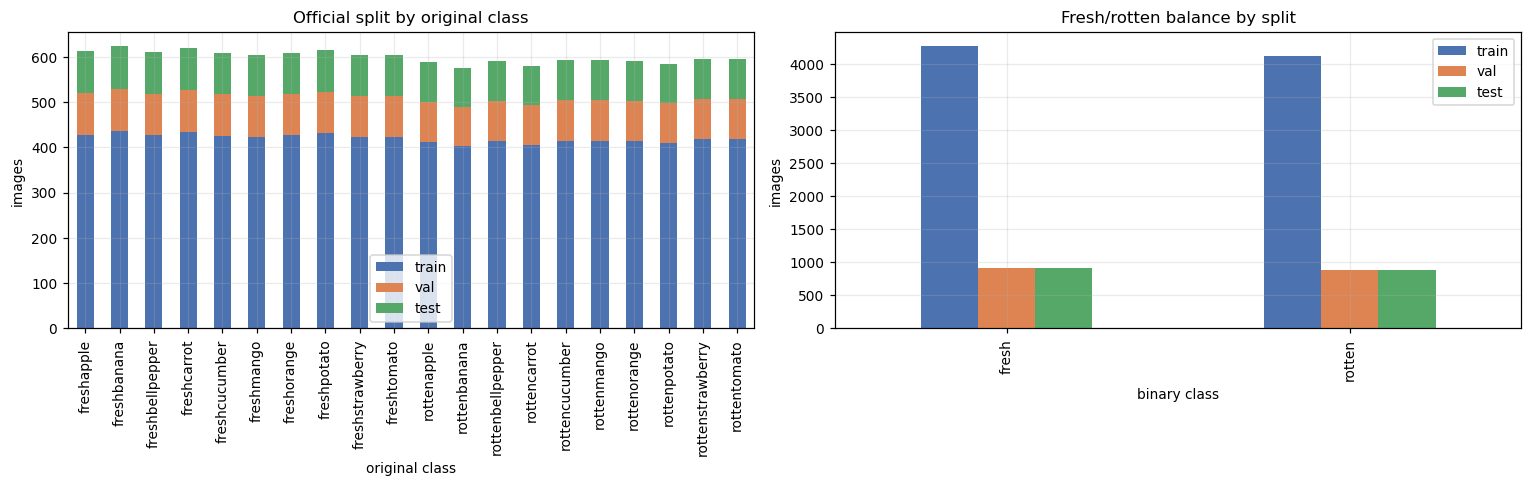

In [3]:
class_counts = split_by_class.reindex(columns=["train", "val", "test"])
binary_counts = binary_by_split.reindex(columns=["train", "val", "test"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
class_counts.plot(kind="bar", stacked=True, ax=axes[0], color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Official split by original class")
axes[0].set_xlabel("original class"); axes[0].set_ylabel("images")
binary_counts.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Fresh/rotten balance by split")
axes[1].set_xlabel("binary class"); axes[1].set_ylabel("images")
plt.tight_layout(); plt.show()

## 3. Preprocessing and frozen feature extraction

This section contains the complete feature-extraction implementation. All images are converted to
RGB. Evaluation preprocessing is deterministic resize to 224×224, tensor conversion and ImageNet
normalisation. Mild augmentation—RandomResizedCrop, horizontal flip, 10° rotation and light
ColorJitter—is enabled only for training. Each augmented training image receives a deterministic
seed based on its row index.

ImageNet-pretrained DenseNet-201, ResNeXt-101-32×8d and ResNet-18 have their final classifier
replaced by `Identity()`, are frozen, placed in `eval()` mode, and executed under `torch.no_grad()`.
Feature files are cached only inside the notebook runtime so interrupted Colab sessions can resume.
No test image is sent through a backbone.

In [4]:
BACKBONE_SPECS = {
    "densenet201": {"dimension": 1920},
    "resnext101": {"dimension": 2048},
    "resnet18": {"dimension": 512},
}


def make_transform(case: str, split: str):
    normalise = [
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
    if case == "aug" and split == "train":
        return transforms.Compose([
            transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.03),
            *normalise,
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        *normalise,
    ])


class FrozenFeatureDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, case: str, split: str):
        if split not in {"train", "val"}:
            raise ValueError("Frozen feature dataset permits train/val only")
        self.frame = frame.reset_index(drop=True)
        self.case = case
        self.split = split
        self.transform = make_transform(case, split)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row["filepath"]) as image:
            image = image.convert("RGB")
            if self.case == "aug" and self.split == "train":
                with torch.random.fork_rng(devices=[]):
                    torch.manual_seed(SEED + index)
                    tensor = self.transform(image)
            else:
                tensor = self.transform(image)
        return tensor, str(row["binary_label"]), str(row["filepath"])


def build_frozen_backbone(name: str):
    if name == "densenet201":
        model = models.densenet201(weights=models.DenseNet201_Weights.DEFAULT)
        model.classifier = nn.Identity()
    elif name == "resnext101":
        model = models.resnext101_32x8d(weights=models.ResNeXt101_32X8D_Weights.DEFAULT)
        model.fc = nn.Identity()
    elif name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model.fc = nn.Identity()
    else:
        raise ValueError(name)
    for parameter in model.parameters():
        parameter.requires_grad = False
    return model.eval().to(DEVICE)


def feature_cache_paths(backbone: str, case: str, split: str):
    prefix = FEATURE_DIR / f"{backbone}_{case}_{split}"
    return {
        "X": prefix.with_name(prefix.name + "_features.npy"),
        "y": prefix.with_name(prefix.name + "_labels.npy"),
        "paths": prefix.with_name(prefix.name + "_paths.npy"),
    }


def extract_feature_split(model, backbone: str, case: str, split: str,
                          frame: pd.DataFrame, batch_size: int = 32):
    if split not in {"train", "val"}:
        raise ValueError("Feature extraction permits train/val only")
    cache = feature_cache_paths(backbone, case, split)
    if all(path.is_file() for path in cache.values()):
        print(f"Loading cached {backbone}/{case}/{split}")
        return {
            "X": np.load(cache["X"], mmap_mode="r"),
            "y": np.load(cache["y"]).astype(str),
            "paths": np.load(cache["paths"]).astype(str),
        }

    split_frame = frame[frame["split"].eq(split)].reset_index(drop=True)
    dataset = FrozenFeatureDataset(split_frame, case=case, split=split)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2,
                        pin_memory=DEVICE.type == "cuda")
    feature_batches, labels, paths = [], [], []
    model.eval()
    with torch.no_grad():
        for images, batch_labels, batch_paths in tqdm(loader, desc=f"{backbone}/{case}/{split}"):
            values = model(images.to(DEVICE, non_blocking=True)).reshape(images.shape[0], -1)
            feature_batches.append(values.cpu().numpy().astype(np.float32, copy=False))
            labels.extend(batch_labels)
            paths.extend(batch_paths)
    X = np.concatenate(feature_batches, axis=0)
    y = np.asarray(labels, dtype=str)
    path_array = np.asarray(paths, dtype=str)
    expected_dimension = BACKBONE_SPECS[backbone]["dimension"]
    if X.shape != (len(split_frame), expected_dimension):
        raise RuntimeError(f"Unexpected {backbone} shape: {X.shape}")
    if not np.array_equal(y, split_frame["binary_label"].astype(str).to_numpy()):
        raise RuntimeError(f"{backbone}/{case}/{split} label order mismatch")
    if not np.array_equal(path_array, split_frame["filepath"].astype(str).to_numpy()):
        raise RuntimeError(f"{backbone}/{case}/{split} path order mismatch")
    np.save(cache["X"], X)
    np.save(cache["y"], y)
    np.save(cache["paths"], path_array)
    return {"X": X, "y": y, "paths": path_array}

In [5]:
FEATURE_SETS = {}

if RUN_FULL_REPRODUCTION:
    for backbone in ("densenet201", "resnext101"):
        print(f"\nPreparing {backbone}")
        backbone_model = build_frozen_backbone(backbone)
        no_aug_train = extract_feature_split(backbone_model, backbone, "no_aug", "train", official_split)
        no_aug_val = extract_feature_split(backbone_model, backbone, "no_aug", "val", official_split)
        aug_train = extract_feature_split(backbone_model, backbone, "aug", "train", official_split)
        # Validation preprocessing is identical in both cases: reuse the same validation features.
        FEATURE_SETS[(backbone, "no_aug")] = {"train": no_aug_train, "val": no_aug_val}
        FEATURE_SETS[(backbone, "aug")] = {"train": aug_train, "val": no_aug_val}
        del backbone_model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    resnet_model = build_frozen_backbone("resnet18")
    resnet_train = extract_feature_split(resnet_model, "resnet18", "no_aug", "train", official_split)
    resnet_val = extract_feature_split(resnet_model, "resnet18", "no_aug", "val", official_split)
    FEATURE_SETS[("resnet18", "no_aug")] = {"train": resnet_train, "val": resnet_val}
    del resnet_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    for key, data in FEATURE_SETS.items():
        print(key, {split: values["X"].shape for split, values in data.items()})
else:
    recorded_feature_shapes = pd.DataFrame([
        {"feature": "DenseNet-201", "train_shape": "(8399, 1920)",
         "validation_shape": "(1801, 1920)", "raw_dimension": 1920},
        {"feature": "ResNeXt-101", "train_shape": "(8399, 2048)",
         "validation_shape": "(1801, 2048)", "raw_dimension": 2048},
        {"feature": "DenseNet + ResNeXt fusion", "train_shape": "(8399, 3968)",
         "validation_shape": "(1801, 3968)", "raw_dimension": 3968},
        {"feature": "Frozen ResNet-18", "train_shape": "(8399, 512)",
         "validation_shape": "(1801, 512)", "raw_dimension": 512},
    ])
    print("Recorded feature-array dimensions (full extraction code is defined above):")
    display(recorded_feature_shapes)

Recorded feature-array dimensions (full extraction code is defined above):


,feature,train_shape,validation_shape,raw_dimension
0,DenseNet-201,"(8399, 1920)","(1801, 1920)",1920
1,ResNeXt-101,"(8399, 2048)","(1801, 2048)",2048
2,DenseNet + ResNeXt fusion,"(8399, 3968)","(1801, 3968)",3968
3,Frozen ResNet-18,"(8399, 512)","(1801, 512)",512


## 4. PCA, classifiers, evaluation and feature fusion

`run_validation_experiment` is structurally validation-only. It fits StandardScaler, optional PCA, and the classifier on the training features, predicts the validation labels, and records all required metrics, per-class reports, confusion matrices, paths, feature dimensions, and runtime. It has no test parameter.

Fusion checks row labels and paths, concatenates DenseNet 1920-d and ResNeXt 2048-d features into
3968 dimensions, then sends the raw fused training matrix through the same training-fitted
StandardScaler/PCA pipeline. This is equivalent to separately scaling the two feature blocks
column by column. PCA is therefore refitted on fused training features, never reused from a
single backbone.

In [6]:
def make_classifier(name: str):
    if name == "svm":
        return SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)
    if name == "lda":
        return LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    if name == "bagging":
        return BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=SEED),
            n_estimators=100, random_state=SEED, n_jobs=-1,
        )
    raise ValueError(name)


def build_pipeline(classifier_name: str, use_pca: bool):
    steps = [("scaler", StandardScaler())]
    if use_pca:
        steps.append(("pca", PCA(n_components=0.95, svd_solver="full", random_state=SEED)))
    steps.append(("classifier", make_classifier(classifier_name)))
    return Pipeline(steps)


def fuse_feature_sets(dense: dict, resnext: dict):
    output = {}
    for split in ("train", "val"):
        dense_split, resnext_split = dense[split], resnext[split]
        if not np.array_equal(dense_split["y"], resnext_split["y"]):
            raise ValueError(f"Fusion label mismatch in {split}")
        if not np.array_equal(dense_split["paths"], resnext_split["paths"]):
            raise ValueError(f"Fusion path/order mismatch in {split}")
        X = np.concatenate([dense_split["X"], resnext_split["X"]], axis=1)
        if X.shape[1] != 3968:
            raise ValueError(f"Expected fusion dimension 3968, found {X.shape[1]}")
        output[split] = {"X": X, "y": dense_split["y"], "paths": dense_split["paths"]}
    return output


RUNS = []
PREDICTIONS = {}
CLASS_REPORTS = {}
CONFUSION_MATRICES = {}
FITTED_MODELS = {}
RUN_CONFIGS = {}


def run_validation_experiment(run_id: str, feature_data: dict, backbone: str,
                              feature_case: str, classifier_name: str, use_pca: bool):
    if set(feature_data) != {"train", "val"}:
        raise ValueError("Experiment data must contain train and val only")
    train, val = feature_data["train"], feature_data["val"]
    model = build_pipeline(classifier_name, use_pca)
    started = time.perf_counter()
    model.fit(train["X"], train["y"])
    predicted = model.predict(val["X"])
    elapsed = time.perf_counter() - started

    macro = precision_recall_fscore_support(
        val["y"], predicted, labels=CLASSES, average="macro", zero_division=0,
    )
    weighted = precision_recall_fscore_support(
        val["y"], predicted, labels=CLASSES, average="weighted", zero_division=0,
    )
    report = pd.DataFrame(classification_report(
        val["y"], predicted, labels=CLASSES, target_names=CLASSES,
        output_dict=True, zero_division=0,
    )).transpose()
    matrix = confusion_matrix(val["y"], predicted, labels=CLASSES)
    pca_dimension = int(model.named_steps["pca"].n_components_) if use_pca else None
    row = {
        "run_id": run_id, "backbone": backbone, "feature_case": feature_case,
        "classifier": classifier_name.upper(), "pca": "PCA(95%)" if use_pca else "none",
        "split": "val", "accuracy": accuracy_score(val["y"], predicted),
        "macro_precision": macro[0], "macro_recall": macro[1], "macro_f1": macro[2],
        "weighted_precision": weighted[0], "weighted_recall": weighted[1],
        "weighted_f1": weighted[2], "raw_dim": train["X"].shape[1],
        "pca_dim": pca_dimension, "seconds": elapsed,
    }
    RUNS.append(row)
    PREDICTIONS[run_id] = {"truth": val["y"], "predicted": predicted, "paths": val["paths"]}
    CLASS_REPORTS[run_id] = report
    CONFUSION_MATRICES[run_id] = matrix
    FITTED_MODELS[run_id] = model
    RUN_CONFIGS[run_id] = {"backbone": backbone, "feature_case": feature_case}
    output_dim = pca_dimension or train["X"].shape[1]
    print(f"{run_id:<42} acc={row['accuracy']:.4f} macroF1={row['macro_f1']:.4f} "
          f"dim={row['raw_dim']}->{output_dim} time={elapsed:.1f}s")
    return row


def plot_confusion_matrix(matrix, title, axis=None):
    axis = axis or plt.subplots(figsize=(3.5, 3.1))[1]
    matrix = np.asarray(matrix)
    axis.imshow(matrix, cmap="Blues")
    axis.set_xticks([0, 1], CLASSES); axis.set_yticks([0, 1], CLASSES)
    axis.set_xlabel("predicted"); axis.set_ylabel("true"); axis.set_title(title, fontsize=9)
    axis.grid(False)
    for row in range(2):
        for column in range(2):
            axis.text(column, row, str(int(matrix[row, column])), ha="center", va="center",
                      color="white" if matrix[row, column] > matrix.max() / 2 else "black")
    return axis

In [7]:
if RUN_FULL_REPRODUCTION:
    FEATURE_SETS[("fusion", "no_aug")] = fuse_feature_sets(
        FEATURE_SETS[("densenet201", "no_aug")], FEATURE_SETS[("resnext101", "no_aug")]
    )
    FEATURE_SETS[("fusion", "aug")] = fuse_feature_sets(
        FEATURE_SETS[("densenet201", "aug")], FEATURE_SETS[("resnext101", "aug")]
    )

    # Complete validation grid: 2 augmentation cases × 3 feature types ×
    # 3 classifiers × 2 PCA settings = 36 validation experiments.
    for backbone in ("densenet201", "resnext101", "fusion"):
        for feature_case in ("no_aug", "aug"):
            data = FEATURE_SETS[(backbone, feature_case)]
            for classifier_name in ("svm", "lda", "bagging"):
                for use_pca in (False, True):
                    run_id = (
                        f"{backbone}_{feature_case}_{classifier_name}_"
                        f"{'pca95' if use_pca else 'nopca'}"
                    )
                    run_validation_experiment(
                        run_id, data, backbone, feature_case, classifier_name, use_pca,
                    )
    run_validation_experiment(
        "resnet18_frozen_no_aug_svm_pca95", FEATURE_SETS[("resnet18", "no_aug")],
        "resnet18_frozen", "no_aug", "svm", True,
    )
    validation_results = pd.DataFrame(RUNS)
else:
    # These are exact validation records already produced by the project. The full code path above
    # is the reproduction implementation; this branch makes its saved outputs visible to markers.
    recorded_stage4 = pd.DataFrame(json.loads(r'''[{"case":"A","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9783453637,"macro_precision":0.9783720758,"macro_recall":0.9783047987,"macro_f1":0.9783357191,"weighted_precision":0.9783492728,"weighted_recall":0.9783453637,"weighted_f1":0.9783446023,"raw_feature_dim":1920,"pca_feature_dim":null,"seconds":17.5144098001},{"case":"A","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9772348695,"macro_precision":0.9775635721,"macro_recall":0.9770427612,"macro_f1":0.9772158757,"weighted_precision":0.9773968389,"weighted_recall":0.9772348695,"weighted_f1":0.97722866,"raw_feature_dim":1920,"pca_feature_dim":null,"seconds":3.6308936998},{"case":"A","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.9405885619,"macro_precision":0.9413454736,"macro_recall":0.9402314846,"macro_f1":0.9405086679,"weighted_precision":0.9410723611,"weighted_recall":0.9405885619,"weighted_f1":0.9405510359,"raw_feature_dim":1920,"pca_feature_dim":null,"seconds":144.3530999001},{"case":"B","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9772348695,"macro_precision":0.9772900589,"macro_recall":0.9771722959,"macro_f1":0.9772236344,"weighted_precision":0.9772471338,"weighted_recall":0.9772348695,"weighted_f1":0.9772334651,"raw_feature_dim":1920,"pca_feature_dim":738.0,"seconds":11.7728217002},{"case":"B","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9644641866,"macro_precision":0.9652461405,"macro_recall":0.9641269242,"macro_f1":0.9644178385,"weighted_precision":0.9649580522,"weighted_recall":0.9644641866,"weighted_f1":0.9644427951,"raw_feature_dim":1920,"pca_feature_dim":738.0,"seconds":3.3058384},{"case":"B","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.9156024431,"macro_precision":0.9164952638,"macro_recall":0.915181953,"macro_f1":0.9154710736,"weighted_precision":0.9162032197,"weighted_recall":0.9156024431,"weighted_f1":0.9155358332,"raw_feature_dim":1920,"pca_feature_dim":738.0,"seconds":40.8690106},{"case":"C","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9494725153,"macro_precision":0.9495759061,"macro_recall":0.9493562745,"macro_f1":0.949442339,"weighted_precision":0.9495076291,"weighted_recall":0.9494725153,"weighted_f1":0.9494663429,"raw_feature_dim":2048,"pca_feature_dim":null,"seconds":27.0965890002},{"case":"C","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9394780677,"macro_precision":0.9414229524,"macro_recall":0.9388830907,"macro_f1":0.9393332276,"weighted_precision":0.9409401796,"weighted_recall":0.9394780677,"weighted_f1":0.9393908345,"raw_feature_dim":2048,"pca_feature_dim":null,"seconds":3.6421196},{"case":"C","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.9272626319,"macro_precision":0.927756849,"macro_recall":0.9269652872,"macro_f1":0.9271818126,"weighted_precision":0.9275533478,"weighted_recall":0.9272626319,"weighted_f1":0.9272289572,"raw_feature_dim":2048,"pca_feature_dim":null,"seconds":128.4478822001},{"case":"D","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9528039978,"macro_precision":0.9529945554,"macro_recall":0.9526458375,"macro_f1":0.9527704496,"weighted_precision":0.952885219,"weighted_recall":0.9528039978,"weighted_f1":0.9527949118,"raw_feature_dim":2048,"pca_feature_dim":1316.0,"seconds":25.3142222001},{"case":"D","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9311493615,"macro_precision":0.9335241659,"macro_recall":0.9304756759,"macro_f1":0.9309572568,"weighted_precision":0.9329879197,"weighted_recall":0.9311493615,"weighted_f1":0.9310280322,"raw_feature_dim":2048,"pca_feature_dim":1316.0,"seconds":5.7030817},{"case":"D","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.8900610772,"macro_precision":0.890333344,"macro_recall":0.8898036502,"macro_f1":0.8899584518,"weighted_precision":0.8902062862,"weighted_recall":0.8900610772,"weighted_f1":0.8900237589,"raw_feature_dim":2048,"pca_feature_dim":1316.0,"seconds":65.6567641001},{"case":"E","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9733481399,"macro_precision":0.9733332676,"macro_recall":0.9735107835,"macro_f1":0.9733451733,"weighted_precision":0.9735067784,"weighted_recall":0.9733481399,"weighted_f1":0.9733506381,"raw_feature_dim":3968,"pca_feature_dim":null,"seconds":33.2271325001},{"case":"E","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9716823987,"macro_precision":0.9720029393,"macro_recall":0.9714881926,"macro_f1":0.9716587722,"weighted_precision":0.9718403462,"weighted_recall":0.9716823987,"weighted_f1":0.9716746746,"raw_feature_dim":3968,"pca_feature_dim":null,"seconds":12.4105414001},{"case":"E","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.947806774,"macro_precision":0.948542251,"macro_recall":0.9474632183,"macro_f1":0.9477387003,"weighted_precision":0.9482712858,"weighted_recall":0.947806774,"weighted_f1":0.9477753554,"raw_feature_dim":3968,"pca_feature_dim":null,"seconds":220.0744959002},{"case":"F","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.973903387,"macro_precision":0.9738538876,"macro_recall":0.9739906784,"macro_f1":0.9738979471,"weighted_precision":0.9739557981,"weighted_recall":0.973903387,"weighted_f1":0.9739052701,"raw_feature_dim":3968,"pca_feature_dim":1796.0,"seconds":713.3109454999},{"case":"F","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9655746807,"macro_precision":0.9657562066,"macro_recall":0.9654321399,"macro_f1":0.96555122,"weighted_precision":0.9656485217,"weighted_recall":0.9655746807,"weighted_f1":0.9655686908,"raw_feature_dim":3968,"pca_feature_dim":1796.0,"seconds":21.1019043},{"case":"F","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.8928373126,"macro_precision":0.8931210372,"macro_recall":0.8931530458,"macro_f1":0.8928371805,"weighted_precision":0.8934413714,"weighted_recall":0.8928373126,"weighted_f1":0.8928394931,"raw_feature_dim":3968,"pca_feature_dim":1796.0,"seconds":117.3400864}]'''))
    recorded_densenet = pd.DataFrame(json.loads(r'''[{"case":"no_aug","classifier":"svm","pca_target":"0.95_variance","pca_components":690,"accuracy":0.9877845641,"macro_precision":0.987802892,"macro_recall":0.9877583599,"macro_f1":0.9877794063,"weighted_f1":0.9877842853,"fit_seconds":4.7478094,"predict_seconds":1.6840527,"total_seconds":6.4318621,"n_train":8399,"n_val":1801,"seed":42},{"case":"no_aug","classifier":"lda","pca_target":"0.95_variance","pca_components":690,"accuracy":0.9700166574,"macro_precision":0.9704278228,"macro_recall":0.9697894384,"macro_f1":0.9699886687,"weighted_f1":0.9700064797,"fit_seconds":0.5254192,"predict_seconds":0.0024733,"total_seconds":0.5278925,"n_train":8399,"n_val":1801,"seed":42},{"case":"no_aug","classifier":"bagging","pca_target":"0.95_variance","pca_components":690,"accuracy":0.9439200444,"macro_precision":0.9439289063,"macro_recall":0.9438664732,"macro_f1":0.9438950674,"weighted_f1":0.9439180725,"fit_seconds":61.4783564,"predict_seconds":0.4618805,"total_seconds":61.9402369,"n_train":8399,"n_val":1801,"seed":42},{"case":"aug","classifier":"svm","pca_target":"0.95_variance","pca_components":738,"accuracy":0.9772348695,"macro_precision":0.9772900589,"macro_recall":0.9771722959,"macro_f1":0.9772236344,"weighted_f1":0.9772334651,"fit_seconds":5.9411231,"predict_seconds":2.2465513,"total_seconds":8.1876744,"n_train":8399,"n_val":1801,"seed":42},{"case":"aug","classifier":"lda","pca_target":"0.95_variance","pca_components":738,"accuracy":0.9677956691,"macro_precision":0.9682704426,"macro_recall":0.9675460218,"macro_f1":0.9677633788,"weighted_f1":0.9677832062,"fit_seconds":0.5975146,"predict_seconds":0.0027813,"total_seconds":0.6002959,"n_train":8399,"n_val":1801,"seed":42},{"case":"aug","classifier":"bagging","pca_target":"0.95_variance","pca_components":738,"accuracy":0.9161576902,"macro_precision":0.9171903708,"macro_recall":0.9157050262,"macro_f1":0.9160159043,"weighted_f1":0.9160829652,"fit_seconds":48.823112,"predict_seconds":0.4644061,"total_seconds":49.2875181,"n_train":8399,"n_val":1801,"seed":42}]'''))
    recorded_resnet_frozen = pd.DataFrame(json.loads(r'''[{"model":"resnet18","case":"no_aug_baseline","classifier":"svm","pca_target":"0.95_variance","pca_components":245,"accuracy":0.9761243753,"macro_precision":0.976178871,"macro_recall":0.9760613821,"macro_f1":0.9761125922,"weighted_f1":0.9761229025,"fit_seconds":1.3050859,"predict_seconds":0.7899296,"total_seconds":2.0950155,"n_train":8399,"n_val":1801,"seed":42}]'''))
    case_to_backbone = {
        "A": "densenet201", "B": "densenet201", "C": "resnext101",
        "D": "resnext101", "E": "fusion", "F": "fusion",
    }
    recorded_rows = []
    for _, row in recorded_stage4.iterrows():
        pca_used = pd.notna(row["pca_feature_dim"])
        recorded_rows.append({
            "run_id": f"{case_to_backbone[row['case']]}_aug_{row['classifier']}_"
                      f"{'pca95' if pca_used else 'nopca'}",
            "backbone": case_to_backbone[row["case"]], "feature_case": "aug",
            "classifier": str(row["classifier"]).upper(),
            "pca": "PCA(95%)" if pca_used else "none", "split": "val",
            "accuracy": row["accuracy"], "macro_precision": row["macro_precision"],
            "macro_recall": row["macro_recall"], "macro_f1": row["macro_f1"],
            "weighted_precision": row["weighted_precision"],
            "weighted_recall": row["weighted_recall"], "weighted_f1": row["weighted_f1"],
            "raw_dim": int(row["raw_feature_dim"]),
            "pca_dim": row["pca_feature_dim"], "seconds": row["seconds"],
        })
    for _, row in recorded_densenet[recorded_densenet["case"].eq("no_aug")].iterrows():
        recorded_rows.append({
            "run_id": f"densenet201_no_aug_{row['classifier']}_pca95",
            "backbone": "densenet201", "feature_case": "no_aug",
            "classifier": str(row["classifier"]).upper(), "pca": "PCA(95%)", "split": "val",
            "accuracy": row["accuracy"], "macro_precision": row["macro_precision"],
            "macro_recall": row["macro_recall"], "macro_f1": row["macro_f1"],
            "weighted_precision": np.nan, "weighted_recall": np.nan,
            "weighted_f1": row["weighted_f1"], "raw_dim": 1920,
            "pca_dim": int(row["pca_components"]), "seconds": row["total_seconds"],
        })
    row = recorded_resnet_frozen.iloc[0]
    recorded_rows.append({
        "run_id": "resnet18_frozen_no_aug_svm_pca95", "backbone": "resnet18_frozen",
        "feature_case": "no_aug", "classifier": "SVM", "pca": "PCA(95%)", "split": "val",
        "accuracy": row["accuracy"], "macro_precision": row["macro_precision"],
        "macro_recall": row["macro_recall"], "macro_f1": row["macro_f1"],
        "weighted_precision": np.nan, "weighted_recall": np.nan,
        "weighted_f1": row["weighted_f1"], "raw_dim": 512,
        "pca_dim": int(row["pca_components"]), "seconds": row["total_seconds"],
    })
    validation_results = pd.DataFrame(recorded_rows)
    print("Displaying embedded real validation outputs; no model was fitted in submission mode.")

validation_results = validation_results.sort_values(
    ["macro_f1", "accuracy", "seconds"], ascending=[False, False, True]
).reset_index(drop=True)
validation_results.index += 1
validation_results.index.name = "validation_rank"
display(validation_results)
validation_results.to_csv(RESULT_DIR / "person5_validation_results.csv", index=True)

Displaying embedded real validation outputs; no model was fitted in submission mode.


,run_id,backbone,feature_case,classifier,pca,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,raw_dim,pca_dim,seconds
validation_rank,,,,,,,,,,,,,,,,
1,densenet201_no_aug_svm_pca95,densenet201,no_aug,SVM,PCA(95%),val,0.9878,0.9878,0.9878,0.9878,NaN,NaN,0.9878,1920,690.0,6.4319
2,densenet201_aug_svm_nopca,densenet201,aug,SVM,none,val,0.9783,0.9784,0.9783,0.9783,0.9783,0.9783,0.9783,1920,NaN,17.5144
3,densenet201_aug_svm_pca95,densenet201,aug,SVM,PCA(95%),val,0.9772,0.9773,0.9772,0.9772,0.9772,0.9772,0.9772,1920,738.0,11.7728
4,densenet201_aug_lda_nopca,densenet201,aug,LDA,none,val,0.9772,0.9776,0.9770,0.9772,0.9774,0.9772,0.9772,1920,NaN,3.6309
5,resnet18_frozen_no_aug_svm_pca95,resnet18_frozen,no_aug,SVM,PCA(95%),val,0.9761,0.9762,0.9761,0.9761,NaN,NaN,0.9761,512,245.0,2.0950
6,fusion_aug_svm_pca95,fusion,aug,SVM,PCA(95%),val,0.9739,0.9739,0.9740,0.9739,0.9740,0.9739,0.9739,3968,1796.0,713.3109
7,fusion_aug_svm_nopca,fusion,aug,SVM,none,val,0.9733,0.9733,0.9735,0.9733,0.9735,0.9733,0.9734,3968,NaN,33.2271
8,fusion_aug_lda_nopca,fusion,aug,LDA,none,val,0.9717,0.9720,0.9715,0.9717,0.9718,0.9717,0.9717,3968,NaN,12.4105
9,densenet201_no_aug_lda_pca95,densenet201,no_aug,LDA,PCA(95%),val,0.9700,0.9704,0.9698,0.9700,NaN,NaN,0.9700,1920,690.0,0.5279


## 5. Previously recorded validation results

The following three small tables are embedded numeric records from the group repository at the
time this notebook was assembled. They preserve existing results if a marker reads the notebook
without rerunning the expensive GPU stages. They are not loaded from external files and are not
used to override a newly executed validation run.

- `recorded_stage4`: augmented DenseNet/ResNeXt/fusion A–F grid.
- `recorded_densenet`: DenseNet PCA(95%) no-augmentation/augmentation comparison.
- `recorded_resnet_frozen`: frozen ResNet-18 validation reference.

No test values appear in these validation tables.

In [8]:
recorded_stage4 = pd.DataFrame(json.loads(r'''[{"case":"A","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9783453637,"macro_precision":0.9783720758,"macro_recall":0.9783047987,"macro_f1":0.9783357191,"weighted_precision":0.9783492728,"weighted_recall":0.9783453637,"weighted_f1":0.9783446023,"raw_feature_dim":1920,"pca_feature_dim":null,"seconds":17.5144098001},{"case":"A","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9772348695,"macro_precision":0.9775635721,"macro_recall":0.9770427612,"macro_f1":0.9772158757,"weighted_precision":0.9773968389,"weighted_recall":0.9772348695,"weighted_f1":0.97722866,"raw_feature_dim":1920,"pca_feature_dim":null,"seconds":3.6308936998},{"case":"A","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.9405885619,"macro_precision":0.9413454736,"macro_recall":0.9402314846,"macro_f1":0.9405086679,"weighted_precision":0.9410723611,"weighted_recall":0.9405885619,"weighted_f1":0.9405510359,"raw_feature_dim":1920,"pca_feature_dim":null,"seconds":144.3530999001},{"case":"B","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9772348695,"macro_precision":0.9772900589,"macro_recall":0.9771722959,"macro_f1":0.9772236344,"weighted_precision":0.9772471338,"weighted_recall":0.9772348695,"weighted_f1":0.9772334651,"raw_feature_dim":1920,"pca_feature_dim":738.0,"seconds":11.7728217002},{"case":"B","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9644641866,"macro_precision":0.9652461405,"macro_recall":0.9641269242,"macro_f1":0.9644178385,"weighted_precision":0.9649580522,"weighted_recall":0.9644641866,"weighted_f1":0.9644427951,"raw_feature_dim":1920,"pca_feature_dim":738.0,"seconds":3.3058384},{"case":"B","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.9156024431,"macro_precision":0.9164952638,"macro_recall":0.915181953,"macro_f1":0.9154710736,"weighted_precision":0.9162032197,"weighted_recall":0.9156024431,"weighted_f1":0.9155358332,"raw_feature_dim":1920,"pca_feature_dim":738.0,"seconds":40.8690106},{"case":"C","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9494725153,"macro_precision":0.9495759061,"macro_recall":0.9493562745,"macro_f1":0.949442339,"weighted_precision":0.9495076291,"weighted_recall":0.9494725153,"weighted_f1":0.9494663429,"raw_feature_dim":2048,"pca_feature_dim":null,"seconds":27.0965890002},{"case":"C","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9394780677,"macro_precision":0.9414229524,"macro_recall":0.9388830907,"macro_f1":0.9393332276,"weighted_precision":0.9409401796,"weighted_recall":0.9394780677,"weighted_f1":0.9393908345,"raw_feature_dim":2048,"pca_feature_dim":null,"seconds":3.6421196},{"case":"C","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.9272626319,"macro_precision":0.927756849,"macro_recall":0.9269652872,"macro_f1":0.9271818126,"weighted_precision":0.9275533478,"weighted_recall":0.9272626319,"weighted_f1":0.9272289572,"raw_feature_dim":2048,"pca_feature_dim":null,"seconds":128.4478822001},{"case":"D","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9528039978,"macro_precision":0.9529945554,"macro_recall":0.9526458375,"macro_f1":0.9527704496,"weighted_precision":0.952885219,"weighted_recall":0.9528039978,"weighted_f1":0.9527949118,"raw_feature_dim":2048,"pca_feature_dim":1316.0,"seconds":25.3142222001},{"case":"D","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9311493615,"macro_precision":0.9335241659,"macro_recall":0.9304756759,"macro_f1":0.9309572568,"weighted_precision":0.9329879197,"weighted_recall":0.9311493615,"weighted_f1":0.9310280322,"raw_feature_dim":2048,"pca_feature_dim":1316.0,"seconds":5.7030817},{"case":"D","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.8900610772,"macro_precision":0.890333344,"macro_recall":0.8898036502,"macro_f1":0.8899584518,"weighted_precision":0.8902062862,"weighted_recall":0.8900610772,"weighted_f1":0.8900237589,"raw_feature_dim":2048,"pca_feature_dim":1316.0,"seconds":65.6567641001},{"case":"E","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9733481399,"macro_precision":0.9733332676,"macro_recall":0.9735107835,"macro_f1":0.9733451733,"weighted_precision":0.9735067784,"weighted_recall":0.9733481399,"weighted_f1":0.9733506381,"raw_feature_dim":3968,"pca_feature_dim":null,"seconds":33.2271325001},{"case":"E","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9716823987,"macro_precision":0.9720029393,"macro_recall":0.9714881926,"macro_f1":0.9716587722,"weighted_precision":0.9718403462,"weighted_recall":0.9716823987,"weighted_f1":0.9716746746,"raw_feature_dim":3968,"pca_feature_dim":null,"seconds":12.4105414001},{"case":"E","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.947806774,"macro_precision":0.948542251,"macro_recall":0.9474632183,"macro_f1":0.9477387003,"weighted_precision":0.9482712858,"weighted_recall":0.947806774,"weighted_f1":0.9477753554,"raw_feature_dim":3968,"pca_feature_dim":null,"seconds":220.0744959002},{"case":"F","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.973903387,"macro_precision":0.9738538876,"macro_recall":0.9739906784,"macro_f1":0.9738979471,"weighted_precision":0.9739557981,"weighted_recall":0.973903387,"weighted_f1":0.9739052701,"raw_feature_dim":3968,"pca_feature_dim":1796.0,"seconds":713.3109454999},{"case":"F","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9655746807,"macro_precision":0.9657562066,"macro_recall":0.9654321399,"macro_f1":0.96555122,"weighted_precision":0.9656485217,"weighted_recall":0.9655746807,"weighted_f1":0.9655686908,"raw_feature_dim":3968,"pca_feature_dim":1796.0,"seconds":21.1019043},{"case":"F","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.8928373126,"macro_precision":0.8931210372,"macro_recall":0.8931530458,"macro_f1":0.8928371805,"weighted_precision":0.8934413714,"weighted_recall":0.8928373126,"weighted_f1":0.8928394931,"raw_feature_dim":3968,"pca_feature_dim":1796.0,"seconds":117.3400864}]'''))
recorded_densenet = pd.DataFrame(json.loads(r'''[{"case":"no_aug","classifier":"svm","pca_target":"0.95_variance","pca_components":690,"accuracy":0.9877845641,"macro_precision":0.987802892,"macro_recall":0.9877583599,"macro_f1":0.9877794063,"weighted_f1":0.9877842853,"fit_seconds":4.7478094,"predict_seconds":1.6840527,"total_seconds":6.4318621,"n_train":8399,"n_val":1801,"seed":42},{"case":"no_aug","classifier":"lda","pca_target":"0.95_variance","pca_components":690,"accuracy":0.9700166574,"macro_precision":0.9704278228,"macro_recall":0.9697894384,"macro_f1":0.9699886687,"weighted_f1":0.9700064797,"fit_seconds":0.5254192,"predict_seconds":0.0024733,"total_seconds":0.5278925,"n_train":8399,"n_val":1801,"seed":42},{"case":"no_aug","classifier":"bagging","pca_target":"0.95_variance","pca_components":690,"accuracy":0.9439200444,"macro_precision":0.9439289063,"macro_recall":0.9438664732,"macro_f1":0.9438950674,"weighted_f1":0.9439180725,"fit_seconds":61.4783564,"predict_seconds":0.4618805,"total_seconds":61.9402369,"n_train":8399,"n_val":1801,"seed":42},{"case":"aug","classifier":"svm","pca_target":"0.95_variance","pca_components":738,"accuracy":0.9772348695,"macro_precision":0.9772900589,"macro_recall":0.9771722959,"macro_f1":0.9772236344,"weighted_f1":0.9772334651,"fit_seconds":5.9411231,"predict_seconds":2.2465513,"total_seconds":8.1876744,"n_train":8399,"n_val":1801,"seed":42},{"case":"aug","classifier":"lda","pca_target":"0.95_variance","pca_components":738,"accuracy":0.9677956691,"macro_precision":0.9682704426,"macro_recall":0.9675460218,"macro_f1":0.9677633788,"weighted_f1":0.9677832062,"fit_seconds":0.5975146,"predict_seconds":0.0027813,"total_seconds":0.6002959,"n_train":8399,"n_val":1801,"seed":42},{"case":"aug","classifier":"bagging","pca_target":"0.95_variance","pca_components":738,"accuracy":0.9161576902,"macro_precision":0.9171903708,"macro_recall":0.9157050262,"macro_f1":0.9160159043,"weighted_f1":0.9160829652,"fit_seconds":48.823112,"predict_seconds":0.4644061,"total_seconds":49.2875181,"n_train":8399,"n_val":1801,"seed":42}]'''))
recorded_resnet_frozen = pd.DataFrame(json.loads(r'''[{"model":"resnet18","case":"no_aug_baseline","classifier":"svm","pca_target":"0.95_variance","pca_components":245,"accuracy":0.9761243753,"macro_precision":0.976178871,"macro_recall":0.9760613821,"macro_f1":0.9761125922,"weighted_f1":0.9761229025,"fit_seconds":1.3050859,"predict_seconds":0.7899296,"total_seconds":2.0950155,"n_train":8399,"n_val":1801,"seed":42}]'''))

assert recorded_stage4["split"].astype(str).str.lower().eq("val").all()
display(recorded_stage4.sort_values("macro_f1", ascending=False).reset_index(drop=True))
display(recorded_densenet.sort_values("macro_f1", ascending=False).reset_index(drop=True))
display(recorded_resnet_frozen)

,case,feature_case,classifier,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,raw_feature_dim,pca_feature_dim,seconds
0,A,aug,svm,val,0.9783,0.9784,0.9783,0.9783,0.9783,0.9783,0.9783,1920,NaN,17.5144
1,B,aug,svm,val,0.9772,0.9773,0.9772,0.9772,0.9772,0.9772,0.9772,1920,738.0,11.7728
2,A,aug,lda,val,0.9772,0.9776,0.9770,0.9772,0.9774,0.9772,0.9772,1920,NaN,3.6309
3,F,aug,svm,val,0.9739,0.9739,0.9740,0.9739,0.9740,0.9739,0.9739,3968,1796.0,713.3109
4,E,aug,svm,val,0.9733,0.9733,0.9735,0.9733,0.9735,0.9733,0.9734,3968,NaN,33.2271
5,E,aug,lda,val,0.9717,0.9720,0.9715,0.9717,0.9718,0.9717,0.9717,3968,NaN,12.4105
6,F,aug,lda,val,0.9656,0.9658,0.9654,0.9656,0.9656,0.9656,0.9656,3968,1796.0,21.1019
7,B,aug,lda,val,0.9645,0.9652,0.9641,0.9644,0.9650,0.9645,0.9644,1920,738.0,3.3058
8,D,aug,svm,val,0.9528,0.9530,0.9526,0.9528,0.9529,0.9528,0.9528,2048,1316.0,25.3142
9,C,aug,svm,val,0.9495,0.9496,0.9494,0.9494,0.9495,0.9495,0.9495,2048,NaN,27.0966


,case,classifier,pca_target,pca_components,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,fit_seconds,predict_seconds,total_seconds,n_train,n_val,seed
0,no_aug,svm,0.95_variance,690,0.9878,0.9878,0.9878,0.9878,0.9878,4.7478,1.6841,6.4319,8399,1801,42
1,aug,svm,0.95_variance,738,0.9772,0.9773,0.9772,0.9772,0.9772,5.9411,2.2466,8.1877,8399,1801,42
2,no_aug,lda,0.95_variance,690,0.9700,0.9704,0.9698,0.9700,0.9700,0.5254,0.0025,0.5279,8399,1801,42
3,aug,lda,0.95_variance,738,0.9678,0.9683,0.9675,0.9678,0.9678,0.5975,0.0028,0.6003,8399,1801,42
4,no_aug,bagging,0.95_variance,690,0.9439,0.9439,0.9439,0.9439,0.9439,61.4784,0.4619,61.9402,8399,1801,42
5,aug,bagging,0.95_variance,738,0.9162,0.9172,0.9157,0.9160,0.9161,48.8231,0.4644,49.2875,8399,1801,42


,model,case,classifier,pca_target,pca_components,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,fit_seconds,predict_seconds,total_seconds,n_train,n_val,seed
0,resnet18,no_aug_baseline,svm,0.95_variance,245,0.9761,0.9762,0.9761,0.9761,0.9761,1.3051,0.7899,2.095,8399,1801,42


## 6. Report figure generated inside the notebook

This is the full plotting logic corresponding to group member 4's report Results figure. It uses
only the embedded validation tables, displays the chart directly, and saves a reproducible copy as
`report_results_pca95_classifier_comparison.png` in the notebook results directory.

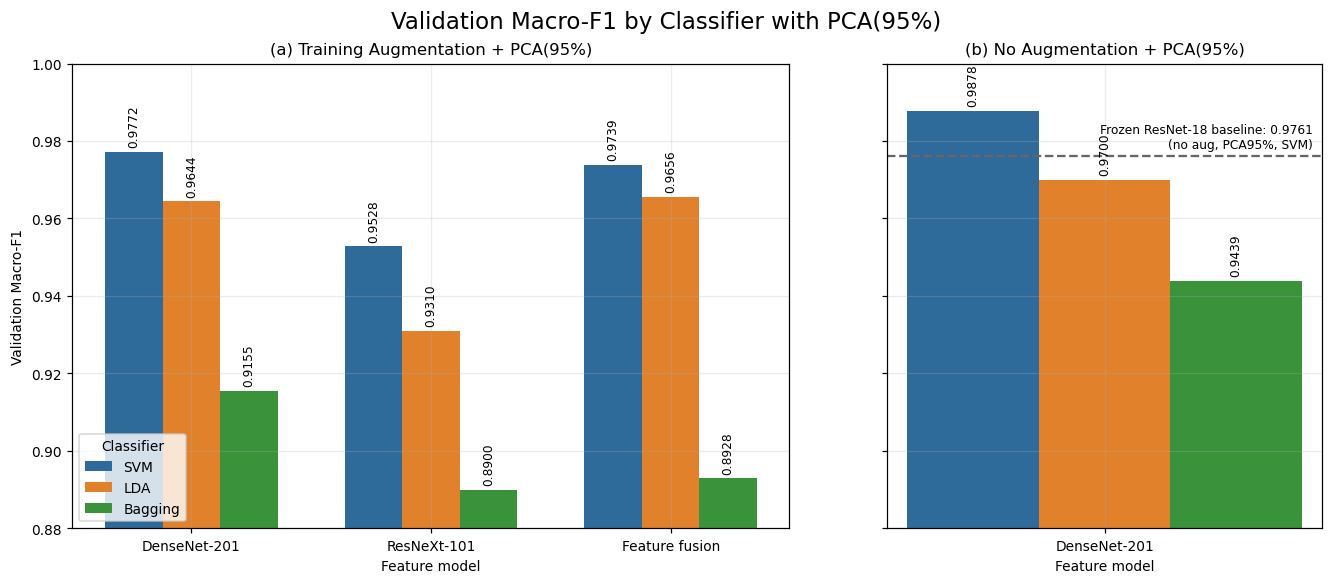

In [9]:
model_cases = {"DenseNet-201": "B", "ResNeXt-101": "D", "Feature fusion": "F"}
classifier_names = ["svm", "lda", "bagging"]
classifier_labels = {"svm": "SVM", "lda": "LDA", "bagging": "Bagging"}
colours = {"svm": "#2F6B9A", "lda": "#E1812C", "bagging": "#3A923A"}


def select_one(frame, mask, description):
    rows = frame.loc[mask]
    if len(rows) != 1:
        raise ValueError(f"Expected one {description} row, found {len(rows)}")
    return rows.iloc[0]


augmented_rows = []
for model_name, case_name in model_cases.items():
    for classifier_name in classifier_names:
        row = select_one(
            recorded_stage4,
            recorded_stage4["case"].astype(str).str.upper().eq(case_name)
            & recorded_stage4["feature_case"].astype(str).str.lower().eq("aug")
            & recorded_stage4["classifier"].astype(str).str.lower().eq(classifier_name)
            & recorded_stage4["pca_feature_dim"].notna(),
            f"{model_name}/{classifier_name}/PCA95 validation",
        )
        augmented_rows.append({"model": model_name, "classifier": classifier_name,
                               "macro_f1": float(row["macro_f1"])})
augmented_plot = pd.DataFrame(augmented_rows)

no_aug_rows = []
for classifier_name in classifier_names:
    row = select_one(
        recorded_densenet,
        recorded_densenet["case"].astype(str).str.lower().eq("no_aug")
        & recorded_densenet["classifier"].astype(str).str.lower().eq(classifier_name)
        & recorded_densenet["pca_target"].astype(str).eq("0.95_variance"),
        f"DenseNet no_aug/{classifier_name}/PCA95 validation",
    )
    no_aug_rows.append({"classifier": classifier_name, "macro_f1": float(row["macro_f1"])})
no_aug_plot = pd.DataFrame(no_aug_rows)

baseline_macro_f1 = float(recorded_resnet_frozen.iloc[0]["macro_f1"])
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True, layout="constrained",
                         gridspec_kw={"width_ratios": [1.65, 1.0], "wspace": 0.14})
bar_width = 0.24
model_names = list(model_cases)
left_x = np.arange(len(model_names))
for index, classifier_name in enumerate(classifier_names):
    values = [float(augmented_plot[
        augmented_plot["model"].eq(model_name)
        & augmented_plot["classifier"].eq(classifier_name)
    ].iloc[0]["macro_f1"]) for model_name in model_names]
    bars = axes[0].bar(left_x + (index - 1) * bar_width, values, bar_width,
                       color=colours[classifier_name], label=classifier_labels[classifier_name])
    axes[0].bar_label(bars, labels=[f"{value:.4f}" for value in values],
                      padding=3, fontsize=8, rotation=90)
for index, classifier_name in enumerate(classifier_names):
    value = float(no_aug_plot[no_aug_plot["classifier"].eq(classifier_name)].iloc[0]["macro_f1"])
    bars = axes[1].bar([(index - 1) * bar_width], [value], bar_width,
                       color=colours[classifier_name])
    axes[1].bar_label(bars, labels=[f"{value:.4f}"], padding=3, fontsize=8, rotation=90)
axes[1].axhline(baseline_macro_f1, color="#666666", linestyle="--", linewidth=1.5)
axes[1].text(0.98, baseline_macro_f1 + 0.0012,
             f"Frozen ResNet-18 baseline: {baseline_macro_f1:.4f}\n(no aug, PCA95%, SVM)",
             transform=axes[1].get_yaxis_transform(), ha="right", va="bottom", fontsize=8)
axes[0].set_title("(a) Training Augmentation + PCA(95%)")
axes[1].set_title("(b) No Augmentation + PCA(95%)")
axes[0].set_xticks(left_x); axes[0].set_xticklabels(model_names)
axes[1].set_xticks([0]); axes[1].set_xticklabels(["DenseNet-201"])
axes[0].set_ylabel("Validation Macro-F1")
for axis in axes:
    axis.set_xlabel("Feature model"); axis.set_ylim(0.88, 1.0); axis.grid(axis="y", alpha=0.25)
axes[0].legend(title="Classifier", loc="lower left")
fig.suptitle("Validation Macro-F1 by Classifier with PCA(95%)", fontsize=15)
report_figure_path = RESULT_DIR / "report_results_pca95_classifier_comparison.png"
fig.savefig(report_figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved report figure: {report_figure_path}")

## 7. Full validation metrics, per-class results and confusion matrices

The live results below include all required aggregate metrics. Per-class Precision/Recall/F1 and
confusion matrices are generated from validation predictions. The displayed major configurations
are the validation-best run for each DenseNet, ResNeXt and fusion augmentation case, plus the
frozen ResNet-18 reference. Full results for every run remain in `CLASS_REPORTS` and
`CONFUSION_MATRICES`.

,backbone,feature_case,classifier,pca,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,raw_dim,pca_dim,seconds
validation_rank,,,,,,,,,,,,
1,densenet201,no_aug,SVM,PCA(95%),0.9878,0.9878,0.9878,0.9878,0.9878,1920,690.0,6.4319
2,densenet201,aug,SVM,none,0.9783,0.9784,0.9783,0.9783,0.9783,1920,NaN,17.5144
3,densenet201,aug,SVM,PCA(95%),0.9772,0.9773,0.9772,0.9772,0.9772,1920,738.0,11.7728
4,densenet201,aug,LDA,none,0.9772,0.9776,0.9770,0.9772,0.9772,1920,NaN,3.6309
5,resnet18_frozen,no_aug,SVM,PCA(95%),0.9761,0.9762,0.9761,0.9761,0.9761,512,245.0,2.0950
6,fusion,aug,SVM,PCA(95%),0.9739,0.9739,0.9740,0.9739,0.9739,3968,1796.0,713.3109
7,fusion,aug,SVM,none,0.9733,0.9733,0.9735,0.9733,0.9734,3968,NaN,33.2271
8,fusion,aug,LDA,none,0.9717,0.9720,0.9715,0.9717,0.9717,3968,NaN,12.4105
9,densenet201,no_aug,LDA,PCA(95%),0.9700,0.9704,0.9698,0.9700,0.9700,1920,690.0,0.5279


Complete recorded Stage-4 validation per-class metrics:


,case,classifier,class,precision,recall,f1-score,support
0,A,svm,fresh,0.9772,0.9804,0.9788,918.0
1,A,svm,rotten,0.9795,0.9762,0.9779,883.0
2,A,lda,fresh,0.9690,0.9869,0.9779,918.0
3,A,lda,rotten,0.9861,0.9672,0.9766,883.0
4,A,bagging,fresh,0.9273,0.9586,0.9427,918.0
5,A,bagging,rotten,0.9554,0.9219,0.9383,883.0
6,B,svm,fresh,0.9751,0.9804,0.9777,918.0
7,B,svm,rotten,0.9795,0.9740,0.9767,883.0
8,B,lda,fresh,0.9504,0.9815,0.9657,918.0
9,B,lda,rotten,0.9801,0.9468,0.9631,883.0


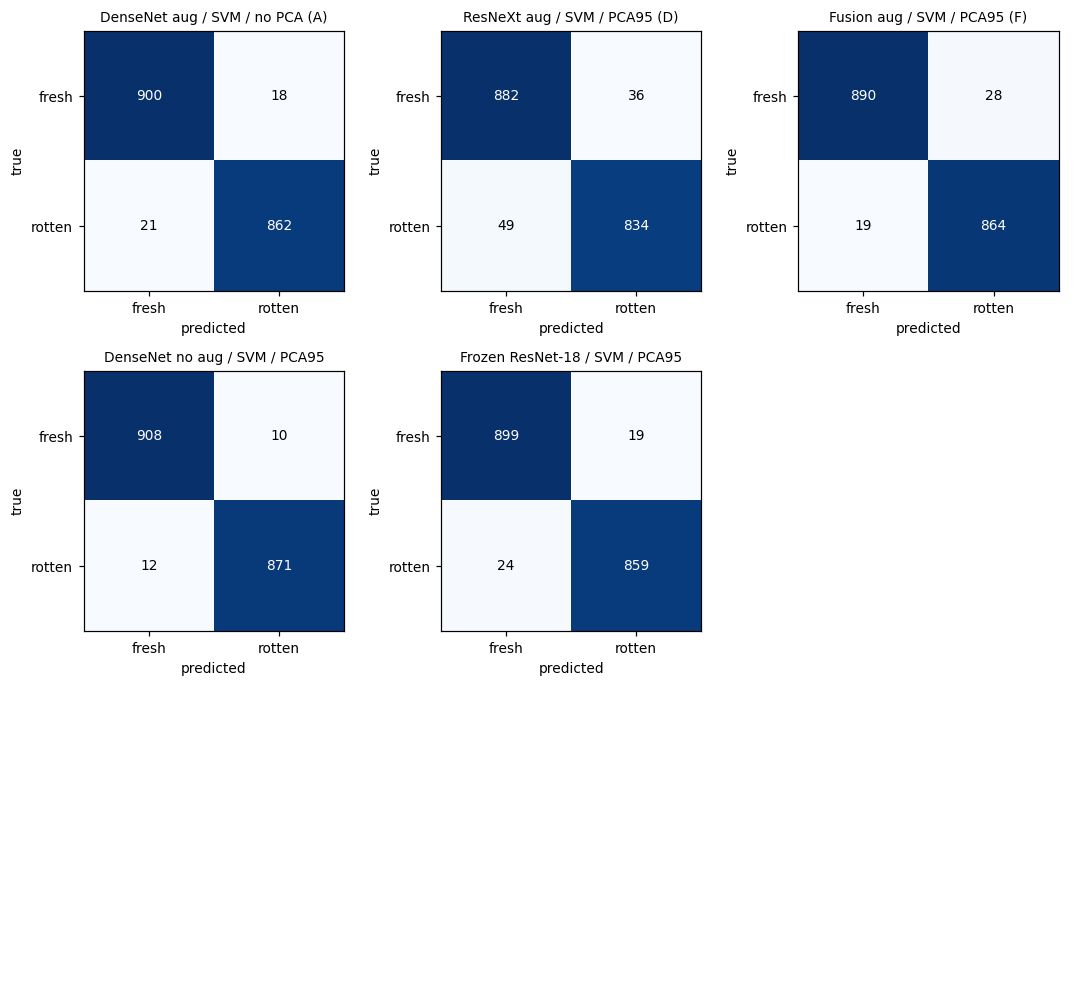

In [10]:
summary_columns = [
    "backbone", "feature_case", "classifier", "pca", "accuracy",
    "macro_precision", "macro_recall", "macro_f1", "weighted_f1",
    "raw_dim", "pca_dim", "seconds",
]
display(validation_results[summary_columns])

if RUN_FULL_REPRODUCTION:
    major_run_ids = []
    for backbone in ("densenet201", "resnext101", "fusion"):
        for feature_case in ("no_aug", "aug"):
            subset = validation_results[
                validation_results["backbone"].eq(backbone)
                & validation_results["feature_case"].eq(feature_case)
            ]
            major_run_ids.append(str(subset.iloc[0]["run_id"]))
    major_run_ids.append("resnet18_frozen_no_aug_svm_pca95")

    per_class_rows = []
    for run_id in major_run_ids:
        report = CLASS_REPORTS[run_id]
        for class_name in CLASSES:
            per_class_rows.append({
                "run_id": run_id, "class": class_name,
                "precision": report.loc[class_name, "precision"],
                "recall": report.loc[class_name, "recall"],
                "f1": report.loc[class_name, "f1-score"],
                "support": int(report.loc[class_name, "support"]),
            })
    display(pd.DataFrame(per_class_rows))
    matrices_to_plot = [(run_id, CONFUSION_MATRICES[run_id]) for run_id in major_run_ids]
else:
    recorded_stage4_per_class = pd.DataFrame(json.loads(r'''[{"case":"A","classifier":"svm","class":"fresh","precision":0.9771986971,"recall":0.9803921569,"f1-score":0.9787928222,"support":918.0},{"case":"A","classifier":"svm","class":"rotten","precision":0.9795454545,"recall":0.9762174405,"f1-score":0.977878616,"support":883.0},{"case":"A","classifier":"svm","class":"accuracy","precision":0.9783453637,"recall":0.9783453637,"f1-score":0.9783453637,"support":0.9783453637},{"case":"A","classifier":"svm","class":"macro avg","precision":0.9783720758,"recall":0.9783047987,"f1-score":0.9783357191,"support":1801.0},{"case":"A","classifier":"svm","class":"weighted avg","precision":0.9783492728,"recall":0.9783453637,"f1-score":0.9783446023,"support":1801.0},{"case":"A","classifier":"lda","class":"fresh","precision":0.9689839572,"recall":0.9869281046,"f1-score":0.9778737183,"support":918.0},{"case":"A","classifier":"lda","class":"rotten","precision":0.9861431871,"recall":0.9671574179,"f1-score":0.9765580332,"support":883.0},{"case":"A","classifier":"lda","class":"accuracy","precision":0.9772348695,"recall":0.9772348695,"f1-score":0.9772348695,"support":0.9772348695},{"case":"A","classifier":"lda","class":"macro avg","precision":0.9775635721,"recall":0.9770427612,"f1-score":0.9772158757,"support":1801.0},{"case":"A","classifier":"lda","class":"weighted avg","precision":0.9773968389,"recall":0.9772348695,"f1-score":0.97722866,"support":1801.0},{"case":"A","classifier":"bagging","class":"fresh","precision":0.9272918862,"recall":0.9586056645,"f1-score":0.9426888056,"support":918.0},{"case":"A","classifier":"bagging","class":"rotten","precision":0.955399061,"recall":0.9218573046,"f1-score":0.9383285303,"support":883.0},{"case":"A","classifier":"bagging","class":"accuracy","precision":0.9405885619,"recall":0.9405885619,"f1-score":0.9405885619,"support":0.9405885619},{"case":"A","classifier":"bagging","class":"macro avg","precision":0.9413454736,"recall":0.9402314846,"f1-score":0.9405086679,"support":1801.0},{"case":"A","classifier":"bagging","class":"weighted avg","precision":0.9410723611,"recall":0.9405885619,"f1-score":0.9405510359,"support":1801.0},{"case":"B","classifier":"svm","class":"fresh","precision":0.9750812568,"recall":0.9803921569,"f1-score":0.9777294948,"support":918.0},{"case":"B","classifier":"svm","class":"rotten","precision":0.979498861,"recall":0.9739524349,"f1-score":0.976717774,"support":883.0},{"case":"B","classifier":"svm","class":"accuracy","precision":0.9772348695,"recall":0.9772348695,"f1-score":0.9772348695,"support":0.9772348695},{"case":"B","classifier":"svm","class":"macro avg","precision":0.9772900589,"recall":0.9771722959,"f1-score":0.9772236344,"support":1801.0},{"case":"B","classifier":"svm","class":"weighted avg","precision":0.9772471338,"recall":0.9772348695,"f1-score":0.9772334651,"support":1801.0},{"case":"B","classifier":"lda","class":"fresh","precision":0.9504219409,"recall":0.9814814815,"f1-score":0.9657020364,"support":918.0},{"case":"B","classifier":"lda","class":"rotten","precision":0.98007034,"recall":0.9467723669,"f1-score":0.9631336406,"support":883.0},{"case":"B","classifier":"lda","class":"accuracy","precision":0.9644641866,"recall":0.9644641866,"f1-score":0.9644641866,"support":0.9644641866},{"case":"B","classifier":"lda","class":"macro avg","precision":0.9652461405,"recall":0.9641269242,"f1-score":0.9644178385,"support":1801.0},{"case":"B","classifier":"lda","class":"weighted avg","precision":0.9649580522,"recall":0.9644641866,"f1-score":0.9644427951,"support":1801.0},{"case":"B","classifier":"bagging","class":"fresh","precision":0.9014675052,"recall":0.9368191721,"f1-score":0.9188034188,"support":918.0},{"case":"B","classifier":"bagging","class":"rotten","precision":0.9315230224,"recall":0.8935447339,"f1-score":0.9121387283,"support":883.0},{"case":"B","classifier":"bagging","class":"accuracy","precision":0.9156024431,"recall":0.9156024431,"f1-score":0.9156024431,"support":0.9156024431},{"case":"B","classifier":"bagging","class":"macro avg","precision":0.9164952638,"recall":0.915181953,"f1-score":0.9154710736,"support":1801.0},{"case":"B","classifier":"bagging","class":"weighted avg","precision":0.9162032197,"recall":0.9156024431,"f1-score":0.9155358332,"support":1801.0},{"case":"C","classifier":"svm","class":"fresh","precision":0.9460625674,"recall":0.9553376906,"f1-score":0.9506775068,"support":918.0},{"case":"C","classifier":"svm","class":"rotten","precision":0.9530892449,"recall":0.9433748584,"f1-score":0.9482071713,"support":883.0},{"case":"C","classifier":"svm","class":"accuracy","precision":0.9494725153,"recall":0.9494725153,"f1-score":0.9494725153,"support":0.9494725153},{"case":"C","classifier":"svm","class":"macro avg","precision":0.9495759061,"recall":0.9493562745,"f1-score":0.949442339,"support":1801.0},{"case":"C","classifier":"svm","class":"weighted avg","precision":0.9495076291,"recall":0.9494725153,"f1-score":0.9494663429,"support":1801.0},{"case":"C","classifier":"lda","class":"fresh","precision":0.9165808445,"recall":0.9694989107,"f1-score":0.9422975119,"support":918.0},{"case":"C","classifier":"lda","class":"rotten","precision":0.9662650602,"recall":0.9082672707,"f1-score":0.9363689434,"support":883.0},{"case":"C","classifier":"lda","class":"accuracy","precision":0.9394780677,"recall":0.9394780677,"f1-score":0.9394780677,"support":0.9394780677},{"case":"C","classifier":"lda","class":"macro avg","precision":0.9414229524,"recall":0.9388830907,"f1-score":0.9393332276,"support":1801.0},{"case":"C","classifier":"lda","class":"weighted avg","precision":0.9409401796,"recall":0.9394780677,"f1-score":0.9393908345,"support":1801.0},{"case":"C","classifier":"bagging","class":"fresh","precision":0.9172852598,"recall":0.9422657952,"f1-score":0.9296077378,"support":918.0},{"case":"C","classifier":"bagging","class":"rotten","precision":0.9382284382,"recall":0.9116647792,"f1-score":0.9247558874,"support":883.0},{"case":"C","classifier":"bagging","class":"accuracy","precision":0.9272626319,"recall":0.9272626319,"f1-score":0.9272626319,"support":0.9272626319},{"case":"C","classifier":"bagging","class":"macro avg","precision":0.927756849,"recall":0.9269652872,"f1-score":0.9271818126,"support":1801.0},{"case":"C","classifier":"bagging","class":"weighted avg","precision":0.9275533478,"recall":0.9272626319,"f1-score":0.9272289572,"support":1801.0},{"case":"D","classifier":"svm","class":"fresh","precision":0.9473684211,"recall":0.9607843137,"f1-score":0.954029205,"support":918.0},{"case":"D","classifier":"svm","class":"rotten","precision":0.9586206897,"recall":0.9445073613,"f1-score":0.9515116942,"support":883.0},{"case":"D","classifier":"svm","class":"accuracy","precision":0.9528039978,"recall":0.9528039978,"f1-score":0.9528039978,"support":0.9528039978},{"case":"D","classifier":"svm","class":"macro avg","precision":0.9529945554,"recall":0.9526458375,"f1-score":0.9527704496,"support":1801.0},{"case":"D","classifier":"svm","class":"weighted avg","precision":0.952885219,"recall":0.9528039978,"f1-score":0.9527949118,"support":1801.0},{"case":"D","classifier":"lda","class":"fresh","precision":0.9059304703,"recall":0.9651416122,"f1-score":0.9345991561,"support":918.0},{"case":"D","classifier":"lda","class":"rotten","precision":0.9611178615,"recall":0.8958097395,"f1-score":0.9273153576,"support":883.0},{"case":"D","classifier":"lda","class":"accuracy","precision":0.9311493615,"recall":0.9311493615,"f1-score":0.9311493615,"support":0.9311493615},{"case":"D","classifier":"lda","class":"macro avg","precision":0.9335241659,"recall":0.9304756759,"f1-score":0.9309572568,"support":1801.0},{"case":"D","classifier":"lda","class":"weighted avg","precision":0.9329879197,"recall":0.9311493615,"f1-score":0.9310280322,"support":1801.0},{"case":"D","classifier":"bagging","class":"fresh","precision":0.8837953092,"recall":0.9030501089,"f1-score":0.8933189655,"support":918.0},{"case":"D","classifier":"bagging","class":"rotten","precision":0.8968713789,"recall":0.8765571914,"f1-score":0.8865979381,"support":883.0},{"case":"D","classifier":"bagging","class":"accuracy","precision":0.8900610772,"recall":0.8900610772,"f1-score":0.8900610772,"support":0.8900610772},{"case":"D","classifier":"bagging","class":"macro avg","precision":0.890333344,"recall":0.8898036502,"f1-score":0.8899584518,"support":1801.0},{"case":"D","classifier":"bagging","class":"weighted avg","precision":0.8902062862,"recall":0.8900610772,"f1-score":0.8900237589,"support":1801.0},{"case":"E","classifier":"svm","class":"fresh","precision":0.9822616408,"recall":0.9651416122,"f1-score":0.9736263736,"support":918.0},{"case":"E","classifier":"svm","class":"rotten","precision":0.9644048943,"recall":0.9818799547,"f1-score":0.9730639731,"support":883.0},{"case":"E","classifier":"svm","class":"accuracy","precision":0.9733481399,"recall":0.9733481399,"f1-score":0.9733481399,"support":0.9733481399},{"case":"E","classifier":"svm","class":"macro avg","precision":0.9733332676,"recall":0.9735107835,"f1-score":0.9733451733,"support":1801.0},{"case":"E","classifier":"svm","class":"weighted avg","precision":0.9735067784,"recall":0.9733481399,"f1-score":0.9733506381,"support":1801.0},{"case":"E","classifier":"lda","class":"fresh","precision":0.9636363636,"recall":0.9814814815,"f1-score":0.9724770642,"support":918.0},{"case":"E","classifier":"lda","class":"rotten","precision":0.980369515,"recall":0.9614949037,"f1-score":0.9708404803,"support":883.0},{"case":"E","classifier":"lda","class":"accuracy","precision":0.9716823987,"recall":0.9716823987,"f1-score":0.9716823987,"support":0.9716823987},{"case":"E","classifier":"lda","class":"macro avg","precision":0.9720029393,"recall":0.9714881926,"f1-score":0.9716587722,"support":1801.0},{"case":"E","classifier":"lda","class":"weighted avg","precision":0.9718403462,"recall":0.9716823987,"f1-score":0.9716746746,"support":1801.0},{"case":"E","classifier":"bagging","class":"fresh","precision":0.9345991561,"recall":0.9651416122,"f1-score":0.949624866,"support":918.0},{"case":"E","classifier":"bagging","class":"rotten","precision":0.9624853458,"recall":0.9297848245,"f1-score":0.9458525346,"support":883.0},{"case":"E","classifier":"bagging","class":"accuracy","precision":0.947806774,"recall":0.947806774,"f1-score":0.947806774,"support":0.947806774},{"case":"E","classifier":"bagging","class":"macro avg","precision":0.948542251,"recall":0.9474632183,"f1-score":0.9477387003,"support":1801.0},{"case":"E","classifier":"bagging","class":"weighted avg","precision":0.9482712858,"recall":0.947806774,"f1-score":0.9477753554,"support":1801.0},{"case":"F","classifier":"svm","class":"fresh","precision":0.9790979098,"recall":0.9694989107,"f1-score":0.9742747674,"support":918.0},{"case":"F","classifier":"svm","class":"rotten","precision":0.9686098655,"recall":0.9784824462,"f1-score":0.9735211268,"support":883.0},{"case":"F","classifier":"svm","class":"accuracy","precision":0.973903387,"recall":0.973903387,"f1-score":0.973903387,"support":0.973903387},{"case":"F","classifier":"svm","class":"macro avg","precision":0.9738538876,"recall":0.9739906784,"f1-score":0.9738979471,"support":1801.0},{"case":"F","classifier":"svm","class":"weighted avg","precision":0.9739557981,"recall":0.973903387,"f1-score":0.9739052701,"support":1801.0},{"case":"F","classifier":"lda","class":"fresh","precision":0.9602150538,"recall":0.9727668845,"f1-score":0.9664502165,"support":918.0},{"case":"F","classifier":"lda","class":"rotten","precision":0.9712973594,"recall":0.9580973952,"f1-score":0.9646522235,"support":883.0},{"case":"F","classifier":"lda","class":"accuracy","precision":0.9655746807,"recall":0.9655746807,"f1-score":0.9655746807,"support":0.9655746807},{"case":"F","classifier":"lda","class":"macro avg","precision":0.9657562066,"recall":0.9654321399,"f1-score":0.96555122,"support":1801.0},{"case":"F","classifier":"lda","class":"weighted avg","precision":0.9656485217,"recall":0.9655746807,"f1-score":0.9655686908,"support":1801.0},{"case":"F","classifier":"bagging","class":"fresh","precision":0.9096045198,"recall":0.8769063181,"f1-score":0.8929561841,"support":918.0},{"case":"F","classifier":"bagging","class":"rotten","precision":0.8766375546,"recall":0.9093997735,"f1-score":0.8927181768,"support":883.0},{"case":"F","classifier":"bagging","class":"accuracy","precision":0.8928373126,"recall":0.8928373126,"f1-score":0.8928373126,"support":0.8928373126},{"case":"F","classifier":"bagging","class":"macro avg","precision":0.8931210372,"recall":0.8931530458,"f1-score":0.8928371805,"support":1801.0},{"case":"F","classifier":"bagging","class":"weighted avg","precision":0.8934413714,"recall":0.8928373126,"f1-score":0.8928394931,"support":1801.0}]'''))
    recorded_class_rows = recorded_stage4_per_class[
        recorded_stage4_per_class["class"].isin(["fresh", "rotten"])
    ].reset_index(drop=True)
    print("Complete recorded Stage-4 validation per-class metrics:")
    display(recorded_class_rows)

    def matrix_from_recorded_report(case, classifier):
        rows = recorded_class_rows[
            recorded_class_rows["case"].eq(case)
            & recorded_class_rows["classifier"].eq(classifier)
        ].set_index("class")
        fresh_correct = round(rows.loc["fresh", "support"] * rows.loc["fresh", "recall"])
        rotten_correct = round(rows.loc["rotten", "support"] * rows.loc["rotten", "recall"])
        return np.asarray([
            [fresh_correct, int(rows.loc["fresh", "support"]) - fresh_correct],
            [int(rows.loc["rotten", "support"]) - rotten_correct, rotten_correct],
        ])

    # Best recorded augmented configuration for each backbone, plus the selected no-augmentation
    # DenseNet and frozen ResNet references. These matrices come from validation predictions.
    matrices_to_plot = [
        ("DenseNet aug / SVM / no PCA (A)", matrix_from_recorded_report("A", "svm")),
        ("ResNeXt aug / SVM / PCA95 (D)", matrix_from_recorded_report("D", "svm")),
        ("Fusion aug / SVM / PCA95 (F)", matrix_from_recorded_report("F", "svm")),
        ("DenseNet no aug / SVM / PCA95", np.asarray([[908, 10], [12, 871]])),
        ("Frozen ResNet-18 / SVM / PCA95", np.asarray([[899, 19], [24, 859]])),
    ]

fig, axes = plt.subplots(3, 3, figsize=(10, 9))
axes = axes.ravel()
for axis, (title, matrix) in zip(axes, matrices_to_plot):
    plot_confusion_matrix(matrix, title, axis)
for axis in axes[len(matrices_to_plot):]:
    axis.axis("off")
plt.tight_layout(); plt.show()

## 8. Validation-only model selection

The live leaderboard is sorted by validation Macro-F1, then Accuracy, then runtime. No test metric
is joined to this table. The previously recorded study selected no-augmentation DenseNet-201 +
PCA(95%) + SVM with validation Macro-F1 0.9878. A complete rerun may differ slightly across
hardware/library versions, any selection below is still based only on validation.

In [13]:
validation_leaderboard = validation_results.copy()
display(validation_leaderboard[summary_columns].head(20))
selected = validation_leaderboard.iloc[0]
SELECTED_RUN_ID = str(selected["run_id"])
print("Validation-selected deep-feature configuration:")
print(selected[summary_columns])

,backbone,feature_case,classifier,pca,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,raw_dim,pca_dim,seconds
validation_rank,,,,,,,,,,,,
1,densenet201,no_aug,SVM,PCA(95%),0.9878,0.9878,0.9878,0.9878,0.9878,1920,690.0,6.4319
2,densenet201,aug,SVM,none,0.9783,0.9784,0.9783,0.9783,0.9783,1920,NaN,17.5144
3,densenet201,aug,SVM,PCA(95%),0.9772,0.9773,0.9772,0.9772,0.9772,1920,738.0,11.7728
4,densenet201,aug,LDA,none,0.9772,0.9776,0.9770,0.9772,0.9772,1920,NaN,3.6309
5,resnet18_frozen,no_aug,SVM,PCA(95%),0.9761,0.9762,0.9761,0.9761,0.9761,512,245.0,2.0950
6,fusion,aug,SVM,PCA(95%),0.9739,0.9739,0.9740,0.9739,0.9739,3968,1796.0,713.3109
7,fusion,aug,SVM,none,0.9733,0.9733,0.9735,0.9733,0.9734,3968,NaN,33.2271
8,fusion,aug,LDA,none,0.9717,0.9720,0.9715,0.9717,0.9717,3968,NaN,12.4105
9,densenet201,no_aug,LDA,PCA(95%),0.9700,0.9704,0.9698,0.9700,0.9700,1920,690.0,0.5279


Validation-selected deep-feature configuration:
backbone           densenet201
feature_case            no_aug
classifier                 SVM
pca                   PCA(95%)
accuracy                0.9878
macro_precision         0.9878
macro_recall            0.9878
macro_f1                0.9878
weighted_f1             0.9878
raw_dim                   1920
pca_dim                  690.0
seconds                 6.4319
Name: 1, dtype: object


## 9. Historical test artifacts

The repository history contains two earlier test evaluations: Case A without PCA and Case B with
PCA(95%). The exact aggregate values, Case B confusion matrix and per-class report are embedded
below so that submitting only this notebook does not lose existing results. These are constants,
not outputs of a new test run. They are not used in model selection, and the notebook contains no
test feature extraction or prediction code.

,artifact,case,feature_case,classifier,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,raw_feature_dim,pca_feature_dim,seconds
0,Historical Case A — no PCA,A,no_aug,svm,test,0.9839,0.9839,0.9838,0.9839,0.9839,1920,NaN,8.6936
1,Historical Case B — PCA(95%),B,no_aug,svm,test,0.9828,0.9829,0.9827,0.9828,0.9828,1920,690.0,16.8045


,class,precision,recall,f1,support
0,fresh,0.9794,0.9869,0.9832,917
1,rotten,0.9863,0.9785,0.9824,883


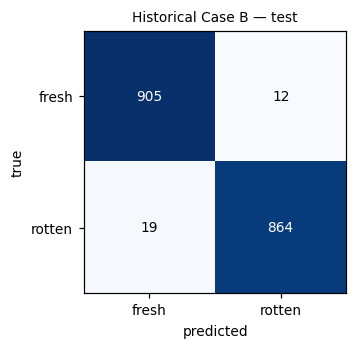

Historical errors: 31
No new test evaluation was performed.


In [14]:
historical_test_results = pd.DataFrame([
    {
        "artifact": "Historical Case A — no PCA", "case": "A", "feature_case": "no_aug",
        "classifier": "svm", "split": "test", "accuracy": 0.9838888888888889,
        "macro_precision": 0.9839471980788521, "macro_recall": 0.9838306506889495,
        "macro_f1": 0.9838813220650806, "weighted_f1": 0.9838879187832723,
        "raw_feature_dim": 1920, "pca_feature_dim": None, "seconds": 8.69360308299838,
    },
    {
        "artifact": "Historical Case B — PCA(95%)", "case": "B", "feature_case": "no_aug",
        "classifier": "svm", "split": "test", "accuracy": 0.9827777777777778,
        "macro_precision": 0.9828692996501216, "macro_recall": 0.9826981478576924,
        "macro_f1": 0.9827688377828127, "weighted_f1": 0.982776251437174,
        "raw_feature_dim": 1920, "pca_feature_dim": 690, "seconds": 16.804477199999383,
    },
])
historical_case_b_cm = pd.DataFrame(
    [[905, 12], [19, 864]], index=CLASSES, columns=CLASSES,
)
historical_case_b_report = pd.DataFrame([
    {"class": "fresh", "precision": 0.9794372294372294, "recall": 0.9869138495092693,
     "f1": 0.9831613253666486, "support": 917},
    {"class": "rotten", "precision": 0.9863013698630136, "recall": 0.9784824462061155,
     "f1": 0.9823763501989767, "support": 883},
])
display(historical_test_results)
display(historical_case_b_report)
plot_confusion_matrix(historical_case_b_cm.to_numpy(), "Historical Case B — test")
plt.show()
print("Historical errors:", int(historical_case_b_cm.to_numpy().sum() - np.trace(historical_case_b_cm)))
print("No new test evaluation was performed.")

## 10. Validation error analysis

Qualitative images come from the selected run's validation predictions, not test. This allows
error interpretation without further test inspection. Rotten→fresh errors are particularly
important because spoiled produce could be accepted as fresh.

In [15]:
if RUN_FULL_REPRODUCTION:
    selected_predictions = PREDICTIONS[SELECTED_RUN_ID]
    wrong_indices = np.flatnonzero(
        selected_predictions["truth"] != selected_predictions["predicted"]
    )
    error_rows = pd.DataFrame({
        "filepath": selected_predictions["paths"][wrong_indices],
        "truth": selected_predictions["truth"][wrong_indices],
        "predicted": selected_predictions["predicted"][wrong_indices],
    })
    display(error_rows.head(30))

    sample_errors = error_rows.head(12)
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    for axis, (_, row) in zip(axes.ravel(), sample_errors.iterrows()):
        with Image.open(row["filepath"]) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"true={row['truth']} → pred={row['predicted']}", fontsize=8)
        axis.axis("off")
    for axis in axes.ravel()[len(sample_errors):]:
        axis.axis("off")
    plt.tight_layout(); plt.show()
else:
    recorded_error_summary = pd.DataFrame([
        {"original_class": "rottenbellpepper", "truth": "rotten", "predicted": "fresh", "errors": 4},
        {"original_class": "freshcarrot", "truth": "fresh", "predicted": "rotten", "errors": 3},
        {"original_class": "rottencarrot", "truth": "rotten", "predicted": "fresh", "errors": 3},
        {"original_class": "rottencucumber", "truth": "rotten", "predicted": "fresh", "errors": 3},
        {"original_class": "freshapple", "truth": "fresh", "predicted": "rotten", "errors": 2},
        {"original_class": "freshbellpepper", "truth": "fresh", "predicted": "rotten", "errors": 2},
        {"original_class": "rottenmango", "truth": "rotten", "predicted": "fresh", "errors": 2},
        {"original_class": "freshcucumber", "truth": "fresh", "predicted": "rotten", "errors": 1},
        {"original_class": "freshorange", "truth": "fresh", "predicted": "rotten", "errors": 1},
        {"original_class": "freshpotato", "truth": "fresh", "predicted": "rotten", "errors": 1},
    ])
    display(recorded_error_summary)
    print("Selected DenseNet validation errors: 22 = 10 fresh→rotten + 12 rotten→fresh.")
    print("Likely causes: subtle spoilage, lighting/background shifts, and overlapping texture cues.")
    print("Image thumbnails require the Kaggle images; full reproduction mode generates them above.")

,original_class,truth,predicted,errors
0,rottenbellpepper,rotten,fresh,4
1,freshcarrot,fresh,rotten,3
2,rottencarrot,rotten,fresh,3
3,rottencucumber,rotten,fresh,3
4,freshapple,fresh,rotten,2
5,freshbellpepper,fresh,rotten,2
6,rottenmango,rotten,fresh,2
7,freshcucumber,fresh,rotten,1
8,freshorange,fresh,rotten,1
9,freshpotato,fresh,rotten,1


Selected DenseNet validation errors: 22 = 10 fresh→rotten + 12 rotten→fresh.
Likely causes: subtle spoilage, lighting/background shifts, and overlapping texture cues.
Image thumbnails require the Kaggle images; full reproduction mode generates them above.


## 11. Training-only PCA and t-SNE visualisation

To keep test isolated, the feature-space plots use a seeded sample of augmented ResNeXt training
features only. PCA/t-SNE are descriptive and are not used for classifier selection.

In [16]:
from sklearn.manifold import TSNE

if RUN_FULL_REPRODUCTION:
    resnext_train = FEATURE_SETS[("resnext101", "aug")]["train"]
    rng = np.random.default_rng(SEED)
    sample_size = min(2000, len(resnext_train["X"]))
    sample_indices = rng.choice(len(resnext_train["X"]), size=sample_size, replace=False)
    features_vis = np.asarray(resnext_train["X"][sample_indices])
    labels_vis = resnext_train["y"][sample_indices]

    pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(features_vis)
    tsne_2d = TSNE(n_components=2, random_state=SEED, perplexity=30,
                   init="pca", learning_rate="auto").fit_transform(features_vis)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
    for axis, embedding, title in [
        (axes[0], pca_2d, "ResNeXt training features — PCA"),
        (axes[1], tsne_2d, "ResNeXt training features — t-SNE"),
    ]:
        for class_name in CLASSES:
            mask = labels_vis == class_name
            axis.scatter(embedding[mask, 0], embedding[mask, 1], s=8, alpha=0.55, label=class_name)
        axis.set_title(title); axis.legend()
    plt.tight_layout(); plt.show()
    print("Visualisation source: train only | rows:", sample_size)
else:
    display(pd.DataFrame([
        {"visualisation": "PCA (2D)", "source_split": "train only", "sample_seed": 42,
         "maximum_rows": 2000, "used_for_selection": False},
        {"visualisation": "t-SNE (2D)", "source_split": "train only", "sample_seed": 42,
         "maximum_rows": 2000, "used_for_selection": False},
    ]))
    print("The complete leakage-safe visualisation code is above; coordinates require live features.")

,visualisation,source_split,sample_seed,maximum_rows,used_for_selection
0,PCA (2D),train only,42,2000,False
1,t-SNE (2D),train only,42,2000,False


The complete leakage-safe visualisation code is above; coordinates require live features.


## 12. Conclusions and limitations

**Recorded validation findings**

- No-augmentation DenseNet-201 + PCA(95%) + SVM recorded validation Macro-F1 0.9878.
- Under matched augmented PCA(95%) + SVM, DenseNet-201 (0.9772) exceeded fusion (0.9739) and
  ResNeXt-101 (0.9528).
- SVM was strongest among the tested classical classifiers. LDA was typically faster, while
  Bagging was weaker and slower on dense CNN embeddings.
- PCA reduced feature dimension/runtime but its performance effect depended on backbone and
  classifier.
- The evaluated mild augmentation policy reduced recorded DenseNet validation Macro-F1. It may
  perturb colour/texture freshness cues, but one seed and one policy do not establish causality.

**Limitations**

- The 20 original categories are collapsed to a binary target.
- The dataset is from one source, external-domain generalisation is not measured.
- Classical hyperparameters were fixed rather than exhaustively tuned.
- Frozen feature augmentation contains one deterministic augmented view per training image.
- A full run is expensive and timings vary by hardware/software.
- Two historical test evaluations exist, so those test numbers are descriptive rather than a
  strictly untouched one-shot assessment. An independent external test set would be needed for a
  new unbiased final assessment. This notebook deliberately does not rerun test.

## 13. Optional prediction demo

The demo uses the validation-selected, already fitted classical pipeline and extracts features
from a user-uploaded image. It does not load validation/test arrays or change any reported result.
The SVM decision score is not a calibrated probability.

In [17]:
def predict_single_image(image_path):
    # Predict one new image after full reproduction has fitted SELECTED_RUN_ID.
    if not RUN_FULL_REPRODUCTION:
        raise RuntimeError("Set RUN_FULL_REPRODUCTION=True and run all preceding cells first.")
    selected_model = FITTED_MODELS[SELECTED_RUN_ID]
    selected_backbone = RUN_CONFIGS[SELECTED_RUN_ID]["backbone"]
    image = Image.open(image_path).convert("RGB")
    tensor = make_transform("no_aug", "val")(image).unsqueeze(0).to(DEVICE)
    parts = []
    with torch.no_grad():
        if selected_backbone in {"densenet201", "fusion"}:
            parts.append(build_frozen_backbone("densenet201")(tensor).cpu().numpy())
        if selected_backbone in {"resnext101", "fusion"}:
            parts.append(build_frozen_backbone("resnext101")(tensor).cpu().numpy())
    features = parts[0] if len(parts) == 1 else np.concatenate(parts, axis=1)
    return str(selected_model.predict(features)[0])


print("Prediction helper defined. It is intentionally not run on validation or test images.")

Prediction helper defined. It is intentionally not run on validation or test images.
